# Probabilistic Learning with Naive Bayes Classification {#naivebayes}

<iframe width="560" height="315" src="https://www.youtube.com/embed/O2L2Uv9pdDA" frameborder="0" allow="accelerometer; autoplay; clipboard-write; encrypted-media; gyroscope; picture-in-picture" allowfullscreen>

</iframe>

In [24]:
import pandas as pd
from pandas.api.types import CategoricalDtype
from IPython.display import display, Markdown
from wordcloud import WordCloud
import matplotlib.pyplot as plt
from matplotlib import colors
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.naive_bayes import MultinomialNB
from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix, accuracy_score

## Business Case: Filtering Spam

In 2020 spam accounted for more than 50% of total e-mail traffic [@noauthor_spam_nodate]. This illustrates the value of a good spam filter. Naive Bayes spam filtering is a standard technique for handling spam. It is one of the oldest ways of doing spam filtering, with roots in the 1990s.

## Data Understanding

The data you'll be using comes from the SMS Spam Collection [@noauthor_uci_spam_nodate]. It contains a set of SMS messages that are labeled 'ham' or 'spam'. and is a standard data set for testing spam filtering methods.

In [25]:
url = "datasets/smsspam.csv"
rawDF = pd.read_csv(url)
rawDF.head()

,type,text
0,ham,"Go until jurong point, crazy.. Available only ..."
1,ham,Ok lar... Joking wif u oni...
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...
3,ham,U dun say so early hor... U c already then say...
4,ham,"Nah I don't think he goes to usf, he lives aro..."


The variable `type` is of class `object` which in Python refers to text. As this variable indicates whether the message belongs to the category ham or spam it is better to convert it to a `category` variable.

In [26]:
catType = CategoricalDtype(categories=["ham", "spam"], ordered=False)
rawDF.type = rawDF.type.astype(catType)
rawDF.type

0        ham
1        ham
2       spam
3        ham
4        ham
        ... 
5567    spam
5568     ham
5569     ham
5570     ham
5571     ham
Name: type, Length: 5572, dtype: category
Categories (2, str): ['ham', 'spam']

To see how the types of sms messages are distributed you can compare the counts for each category.

In [27]:
rawDF.type.value_counts()

type
ham     4825
spam     747
Name: count, dtype: int64

Often you'll prefer the relative counts.

In [28]:
rawDF.type.value_counts(normalize=True)

type
ham     0.865937
spam    0.134063
Name: proportion, dtype: float64

You can also visually inspect the data by creating wordclouds for each sms type.

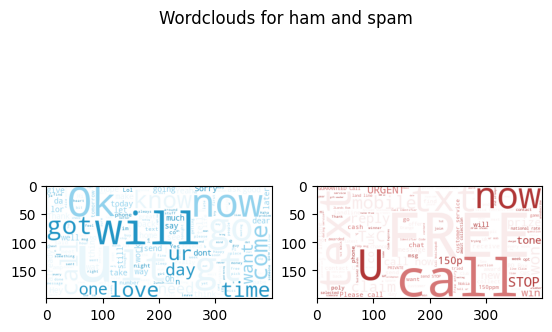

In [29]:
# Generate a word cloud image]
hamText = ' '.join([Text for Text in rawDF[rawDF['type']=='ham']['text']])
spamText = ' '.join([Text for Text in rawDF[rawDF['type']=='spam']['text']])
colorListHam=['#e9f6fb','#92d2ed','#2195c5']
colorListSpam=['#f9ebeb','#d57676','#b03636']
colormapHam=colors.ListedColormap(colorListHam)
colormapSpam=colors.ListedColormap(colorListSpam)
wordcloudHam = WordCloud(background_color='white', colormap=colormapHam).generate(hamText)
wordcloudSpam = WordCloud(background_color='white', colormap=colormapSpam).generate(spamText)

# Display the generated image:
# the matplotlib way:
fig, (wc1, wc2) = plt.subplots(1, 2)
fig.suptitle('Wordclouds for ham and spam')
wc1.imshow(wordcloudHam)
wc2.imshow(wordcloudSpam)
plt.show()

**Question:**

-   *What differences do you notice?*

## Preparation

After you've glimpsed over the data and have a certain understanding of its structure and content, you are now ready to prepare the data for further processing. For the naive bayes model you'll need to have a dataframe with wordcounts. To save on computation time you can set a limit on the number of features (columns) in the wordsDF dataframe.

In [30]:
vectorizer = TfidfVectorizer(max_features=1000)
vectors = vectorizer.fit_transform(rawDF.text)
wordsDF = pd.DataFrame(vectors.toarray(), columns=vectorizer.get_feature_names_out())
wordsDF.head()

,000,03,04,0800,08000839402,08000930705,10,100,1000,10p,...,yes,yesterday,yet,yo,you,your,yours,yourself,yr,yup
0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


The counts are normalized in such a way that the words that are most likely to have predictive power get heavier weights. For instance stopword like *"a"* and *"for"* most probably will equally likely feature in spam as in ham messages. Therefore these words will be assigned lower normalized counts.

Before we start modeling we need to split all datasets into *train* and *test* sets. The function *train_test_split`()`* can be used to create balanced splits of the data. In this case we'll create a 75/25% split.

In [31]:
xTrain, xTest, yTrain, yTest = train_test_split(wordsDF, rawDF.type)

## Modeling and Evaluation

We have now everything in place to start training our model and evaluate against our test dataset. The `MultinomialNB().fit()` function is part of the `scikit learn` package. It takes in the features and labels of our training dataset and returns a trained naive bayes model.

In [32]:
bayes = MultinomialNB()
bayes.fit(xTrain, yTrain)

,"alpha alpha: float or array-like of shape (n_features,), default=1.0Additive (Laplace/Lidstone) smoothing parameter(set alpha=0 and force_alpha=True, for no smoothing).",1.0
,"force_alpha force_alpha: bool, default=TrueIf False and alpha is less than 1e-10, it will set alpha to1e-10. If True, alpha will remain unchanged. This may causenumerical errors if alpha is too close to 0... versionadded:: 1.2.. versionchanged:: 1.4 The default value of `force_alpha` changed to `True`.",True
,"fit_prior fit_prior: bool, default=TrueWhether to learn class prior probabilities or not.If false, a uniform prior will be used.",True
,"class_prior class_prior: array-like of shape (n_classes,), default=NonePrior probabilities of the classes. If specified, the priors are notadjusted according to the data.",None


The model can be applied to the test features using the `predict()` function which generates a array of predictions. Using a confusion matrix we can analyze the performance of our model.

```{r difftable1-fig, echo=FALSE, fig.align='center', fig.asp=.75, fig.cap='Standard diffusion table. Taken from: https://emj.bmj.com/content/emermed/36/7/431/F1.large.jpg', message=TRUE, warning=TRUE, out.width='80%'}
knitr::include_graphics(rep('images/diffusion.png'))
```

In [33]:
yPred = bayes.predict(xTest)
yTrue = yTest

In [34]:
accuracyScore = accuracy_score(yTrue, yPred)
print(f'Accuracy: {accuracyScore}')
matrix = confusion_matrix(yTrue, yPred)
labelNames = pd.Series(['ham', 'spam'])
pd.DataFrame(matrix,
     columns='Predicted ' + labelNames,
     index='Is ' + labelNames)

Accuracy: 0.9720028715003589


,Predicted ham,Predicted spam
Is ham,1194,3
Is spam,36,160


**Questions:**

1.  *What do you think is the role of the `alpha` parameter in the `MultinomialNB()` function?*
2.  *How would you assess the overall performance of the model?*
3.  *What would you consider as more costly: high false negatives or high false positives levels? Why?*

## Export Model

To use the trained model in a standalone app, we export the fitted vectorizer and model using `joblib`. Run the cell below to save them to the `spam-classifier-app/model/` folder.

In [ ]:
import joblib
import os

os.makedirs("spam-classifier-app/model", exist_ok=True)
joblib.dump(vectorizer, "spam-classifier-app/model/vectorizer.joblib")
joblib.dump(bayes, "spam-classifier-app/model/model.joblib")
print("Model and vectorizer exported to spam-classifier-app/model/")